In [38]:
# %% Cell 1 — Imports
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from autoreject import AutoReject

mne.set_log_level("WARNING")


def status(msg):
    print(f"\n[{time.strftime('%H:%M:%S')}] {msg}")

In [39]:
# %% Cell 2 — Load Stage-2 checkpoint & inspect triggers

CONFIG = {
    "results_dir": Path(r"Z:\Misophonia_EEG"),
    "subject": "103",
}

sub = CONFIG["subject"]
out_dir = CONFIG["results_dir"] / sub

status(f"Loading Stage-2 checkpoint for subject {sub}...")

raw_file = out_dir / f"{sub}_stage2_cleaned_raw.fif"
events_file = out_dir / f"{sub}_stage1_events.npy"
event_id_file = out_dir / f"{sub}_stage1_event_id.json"

for file in [raw_file, events_file, event_id_file]:
    if not file.exists():
        raise FileNotFoundError(f"Missing file: {file}")

raw = mne.io.read_raw_fif(
    raw_file,
    preload=True,
)

events = np.load(events_file)

with open(event_id_file) as f:
    event_id = json.load(f)

montage = raw.get_montage()

print(
    f"Loaded: {raw.info['sfreq']} Hz, "
    f"{len(raw.ch_names)} channels, "
    f"{len(events)} events"
)

print("event_id:", event_id)

print(
    f"Montage: "
    f"{len(montage.ch_names) if montage else 0} positions"
)

print(f"\nTotal events: {len(events)}")

for label, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"  {label}: {count}")


[17:39:59] Loading Stage-2 checkpoint for subject 103...
Loaded: 250.0 Hz, 29 channels, 202 events
event_id: {'Unpleasant': 1, 'Neutral': 2, 'Pleasant': 4, 'Unpleasant_noise': 8, 'Pleasant_noise': 16}
Montage: 26 positions

Total events: 202
  Unpleasant: 41
  Neutral: 40
  Pleasant: 41
  Unpleasant_noise: 40
  Pleasant_noise: 40


In [40]:
# %% Cell 3 — Finalize events for analysis

# Exclude first two events only when exactly 202 are present
if len(events) == 202:
    status(
        "Exactly 202 events detected — "
        "excluding the first 2 events."
    )
    events = events[2:].copy()

elif len(events) < 202:
    status(
        f"{len(events)} events detected (<202) — "
        "keeping all events."
    )

else:
    raise ValueError(
        f"Unexpected number of events: {len(events)}. "
        "More than 202 events found."
    )

print(f"\nEvents used for analysis: {len(events)}")

for label, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"  {label}: {count}")


[17:40:38] Exactly 202 events detected — excluding the first 2 events.

Events used for analysis: 200
  Unpleasant: 40
  Neutral: 40
  Pleasant: 40
  Unpleasant_noise: 40
  Pleasant_noise: 40


In [41]:
# %% Cell 4 — Define ERP regions of interest (ROIs)

# Early auditory ERP components: P1, N1, P2
EARLY_ERP_ROI = [
    "F3", "Fz", "F4",
    "FC3", "FCz", "FC4",
    "C3", "Cz", "C4",
]

# Late positive potential: LPP
LPP_ROI = [
    "CP3", "CPz", "CP4",
    "P3", "Pz", "P4",
    "O1", "Oz", "O2",
]

ERP_ROI = EARLY_ERP_ROI + LPP_ROI

missing_roi = [
    ch for ch in ERP_ROI
    if ch not in raw.ch_names
]

if missing_roi:
    raise ValueError(
        f"Missing ERP ROI channels: {missing_roi}"
    )

print("\nERP regions of interest:")
print(f"  P1/N1/P2: {EARLY_ERP_ROI}")
print(f"  LPP:       {LPP_ROI}")
print(f"  Total ROI channels: {len(ERP_ROI)}")


ERP regions of interest:
  P1/N1/P2: ['F3', 'Fz', 'F4', 'FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4']
  LPP:       ['CP3', 'CPz', 'CP4', 'P3', 'Pz', 'P4', 'O1', 'Oz', 'O2']
  Total ROI channels: 18


In [42]:
# %% Cell 5 — Create master epochs
#
# This is the common starting point for BOTH artifact-cleaning methods.
# No artifact rejection is performed here.

EPOCH_TMIN = -0.2
EPOCH_TMAX = 3.0
BASELINE = (-0.2, 0)

status("Constructing master baseline-corrected epochs...")

epochs_master = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=EPOCH_TMIN,
    tmax=EPOCH_TMAX,
    baseline=BASELINE,
    picks="eeg",
    preload=True,
    reject=None,
    detrend=None,
)

print(f"\nMaster epochs: {len(epochs_master)}")
print(f"Time range: {epochs_master.tmin:.3f} to {epochs_master.tmax:.3f} s")
print(f"Sampling frequency: {epochs_master.info['sfreq']:.2f} Hz")
print(f"EEG channels: {len(epochs_master.ch_names)}")

for label in event_id:
    print(f"  {label}: {len(epochs_master[label])}")


[17:42:34] Constructing master baseline-corrected epochs...

Master epochs: 200
Time range: -0.200 to 3.000 s
Sampling frequency: 250.00 Hz
EEG channels: 26
  Unpleasant: 40
  Neutral: 40
  Pleasant: 40
  Unpleasant_noise: 40
  Pleasant_noise: 40


In [43]:
# %% Cell 6 — Add trial metadata

condition_labels = {
    v: k for k, v in event_id.items()
}

epochs_master.metadata = pd.DataFrame({
    "subject": [sub] * len(epochs_master),

    "condition": [
        condition_labels[code]
        for code in epochs_master.events[:, 2]
    ],

    "event_code": epochs_master.events[:, 2],

    "trial_number": np.arange(
        len(epochs_master)
    ),

    "original_event_index": np.arange(
        len(epochs_master)
    ),
})

print("\nMetadata preview:")
print(epochs_master.metadata.head())


Metadata preview:
  subject       condition  event_code  trial_number  original_event_index
0     103         Neutral           2             0                     0
1     103        Pleasant           4             1                     1
2     103      Unpleasant           1             2                     2
3     103        Pleasant           4             3                     3
4     103  Pleasant_noise          16             4                     4


In [45]:
# %% Cell 7 — Calculate artifact metrics
#
# Metrics are calculated for every channel × epoch.
# No epochs are dropped and no channels are interpolated here.

status("Calculating artifact metrics...")

eeg_picks = mne.pick_types(
    epochs_master.info,
    eeg=True,
    exclude=[]
)

data_uv = (
    epochs_master.get_data(
        picks=eeg_picks
    ) * 1e6
)

ch_names = [
    epochs_master.ch_names[i]
    for i in eeg_picks
]

sfreq = epochs_master.info["sfreq"]

n_epochs, n_channels, n_times = data_uv.shape

print(f"Data shape: {data_uv.shape}")
print(f"Sampling frequency: {sfreq:.2f} Hz")
print(f"EEG channels: {n_channels}")

# 1. Maximum voltage gradient
ms_per_sample = 1000.0 / sfreq

gradient = (
    np.abs(np.diff(data_uv, axis=2))
    / ms_per_sample
)

max_gradient = gradient.max(axis=2)

# 2. Maximum 500-ms peak-to-peak amplitude
window_samples = int(
    round(0.5 * sfreq)
)

window_max_ptp = np.zeros(
    (n_epochs, n_channels)
)

step = max(1, window_samples // 4)

for start in range(
    0,
    n_times - window_samples + 1,
    step
):
    stop = start + window_samples

    window = data_uv[:, :, start:stop]

    ptp = (
        window.max(axis=2)
        - window.min(axis=2)
    )

    window_max_ptp = np.maximum(
        window_max_ptp,
        ptp
    )

# 3. Maximum absolute amplitude
max_abs_amplitude = (
    np.abs(data_uv).max(axis=2)
)


def summarize_metric(values, name, unit):
    values = np.asarray(values).ravel()

    return pd.Series({
        "metric": name,
        "unit": unit,
        "mean": np.mean(values),
        "SD": np.std(values, ddof=1),
        "median": np.median(values),
        "IQR": (
            np.percentile(values, 75)
            - np.percentile(values, 25)
        ),
        "min": np.min(values),
        "P01": np.percentile(values, 1),
        "P05": np.percentile(values, 5),
        "P25": np.percentile(values, 25),
        "P75": np.percentile(values, 75),
        "P95": np.percentile(values, 95),
        "P99": np.percentile(values, 99),
        "max": np.max(values),
    })


metric_summary = pd.DataFrame([
    summarize_metric(
        max_gradient,
        "Maximum gradient per channel × epoch",
        "µV/ms"
    ),
    summarize_metric(
        window_max_ptp,
        "Maximum 500-ms PTP per channel × epoch",
        "µV"
    ),
    summarize_metric(
        max_abs_amplitude,
        "Maximum absolute amplitude per channel × epoch",
        "µV"
    ),
])

print("\nArtifact metric distributions:")
print(
    metric_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


[17:45:23] Calculating artifact metrics...
Data shape: (200, 26, 801)
Sampling frequency: 250.00 Hz
EEG channels: 26

Artifact metric distributions:
                                        metric  unit  mean    SD  median   IQR   min   P01   P05   P25   P75   P95    P99    max
          Maximum gradient per channel × epoch µV/ms  1.43  0.67    1.31  0.48  0.61  0.76  0.88  1.10  1.58  2.27   3.65  13.59
        Maximum 500-ms PTP per channel × epoch    µV 28.38  9.75   27.07  9.23 12.45 15.72 18.31 22.93 32.16 41.92  51.76 237.33
Maximum absolute amplitude per channel × epoch    µV 33.22 19.16   27.78 19.79  7.68 11.21 13.76 20.40 40.19 71.67 100.04 239.09


In [46]:
# %% Cell 8 — Apply artifact screening thresholds

GRADIENT_THRESHOLD = 5          # µV/ms
WINDOW_PTP_THRESHOLD = 100      # µV
ABS_AMPLITUDE_THRESHOLD = 100    # µV

gradient_bad = max_gradient > GRADIENT_THRESHOLD
window_bad = window_max_ptp > WINDOW_PTP_THRESHOLD
abs_bad = max_abs_amplitude > ABS_AMPLITUDE_THRESHOLD

combined_bad = gradient_bad | window_bad | abs_bad

print("\nArtifact screening thresholds:")
print(f"  Gradient:     > {GRADIENT_THRESHOLD} µV/ms")
print(f"  500-ms PTP:   > {WINDOW_PTP_THRESHOLD} µV")
print(f"  Absolute amp: > {ABS_AMPLITUDE_THRESHOLD} µV")

print("\nFlagged channel × epoch observations:")
print(f"  Gradient:     {gradient_bad.sum():,}")
print(f"  500-ms PTP:   {window_bad.sum():,}")
print(f"  Absolute amp: {abs_bad.sum():,}")
print(f"  Combined:     {combined_bad.sum():,}")

print("\nAffected epochs:")
for name, mask in [
    ("Gradient", gradient_bad),
    ("500-ms PTP", window_bad),
    ("Absolute amp", abs_bad),
    ("Combined", combined_bad),
]:
    print(f"  {name}: {np.any(mask, axis=1).sum()} / {n_epochs}")


Artifact screening thresholds:
  Gradient:     > 5 µV/ms
  500-ms PTP:   > 100 µV
  Absolute amp: > 100 µV

Flagged channel × epoch observations:
  Gradient:     19
  500-ms PTP:   7
  Absolute amp: 53
  Combined:     65

Affected epochs:
  Gradient: 14 / 200
  500-ms PTP: 7 / 200
  Absolute amp: 36 / 200
  Combined: 40 / 200


In [47]:
# %% Cell 9 — Summarize channel-level artifact burden
#
# Calculate the percentage of epochs in which each channel
# was flagged by the combined artifact criteria.

channel_diagnostics = pd.DataFrame({
    "channel": ch_names,
    "combined_n": combined_bad.sum(axis=0),
    "combined_pct": 100 * combined_bad.mean(axis=0),
})

print("\nChannel-level artifact burden:")
print(
    channel_diagnostics
    .sort_values("combined_pct", ascending=False)
    .to_string(index=False)
)


Channel-level artifact burden:
channel  combined_n  combined_pct
     F3          11           5.5
     Cz           9           4.5
     Pz           9           4.5
     M1           8           4.0
    FC3           6           3.0
     P7           5           2.5
     O1           4           2.0
    CPz           4           2.0
     F7           2           1.0
    FC4           2           1.0
     Oz           2           1.0
     M2           2           1.0
     O2           1           0.5
     T7           0           0.0
     Fz           0           0.0
     F4           0           0.0
    FCz           0           0.0
     F8           0           0.0
     C3           0           0.0
     C4           0           0.0
     T8           0           0.0
    CP3           0           0.0
    CP4           0           0.0
     P3           0           0.0
     P4           0           0.0
     P8           0           0.0


In [48]:
# %% Cell 10 — Final artifact decisions
#
# Decision hierarchy:
#
# 1. Persistent channel:
#       >50% of epochs artifact-flagged
#       → exclude channel for this participant
#
# 2. Whole-epoch rejection:
#       >=4 usable ERP-ROI channels artifact-flagged
#       → reject entire epoch
#
# 3. Retained epoch with 1–3 bad channels:
#       → keep epoch
#       → exclude affected channels from that epoch's ERP average

status("Applying rule-based artifact decisions...")

PERSISTENT_CHANNEL_THRESHOLD = 50  # 
EPOCH_REJECT_N_ROI = 4

# ---------------------------------------------------------
# 1. Persistent channels
# ---------------------------------------------------------

persistent_channels = channel_diagnostics.loc[
    channel_diagnostics["combined_pct"] > PERSISTENT_CHANNEL_THRESHOLD,
    "channel"
].tolist()

print("\nPersistent channels:")
print(persistent_channels if persistent_channels else "None")


# ---------------------------------------------------------
# 2. Usable ERP ROI
# ---------------------------------------------------------

usable_roi_channels = [
    ch for ch in ERP_ROI
    if ch not in persistent_channels
]

usable_roi_idx = [
    ch_names.index(ch)
    for ch in usable_roi_channels
]

print("\nERP ROI:")
print(f"  Original: {len(ERP_ROI)}")
print(f"  Persistent exclusions: {len(persistent_channels)}")
print(f"  Usable: {len(usable_roi_channels)}")


# ---------------------------------------------------------
# 3. Channel × epoch artifact mask
# ---------------------------------------------------------

roi_bad = combined_bad[:, usable_roi_idx]


# ---------------------------------------------------------
# 4. Number of bad ERP channels per epoch
# ---------------------------------------------------------

bad_channels_usable_roi = roi_bad.sum(axis=1)


# ---------------------------------------------------------
# 5. Whole-epoch rejection
# ---------------------------------------------------------

epoch_reject_rule = (
    bad_channels_usable_roi >= EPOCH_REJECT_N_ROI
)

epoch_keep_rule = ~epoch_reject_rule


# ---------------------------------------------------------
# 6. Channel usability
# ---------------------------------------------------------

channel_usable_rule = ~roi_bad


# ---------------------------------------------------------
# 7. Record artifact information in metadata
# ---------------------------------------------------------

metadata_rule = epochs_master.metadata.copy()

metadata_rule["bad_erp_channel_count"] = (
    bad_channels_usable_roi
)

metadata_rule["rule_epoch_rejected"] = (
    epoch_reject_rule
)


# Specific bad ERP channels for EACH epoch
bad_channel_names = []

for epoch_i in range(n_epochs):

    bad_names = [
        usable_roi_channels[ch_i]
        for ch_i in np.where(roi_bad[epoch_i])[0]
    ]

    bad_channel_names.append(
        ";".join(bad_names) if bad_names else ""
    )

metadata_rule["bad_erp_channels"] = bad_channel_names


# ---------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("RULE-BASED ARTIFACT RESULTS")
print("=" * 60)

print(
    f"Rejected epochs: "
    f"{epoch_reject_rule.sum()} / {n_epochs}"
)

print(
    f"Retained epochs: "
    f"{epoch_keep_rule.sum()} / {n_epochs}"
)

print(
    f"Retention: "
    f"{100 * epoch_keep_rule.mean():.1f}%"
)

print("\nBad ERP channels per retained epoch:")

print(
    pd.Series(
        bad_channels_usable_roi[epoch_keep_rule]
    )
    .value_counts()
    .sort_index()
    .to_string()
)


[17:47:48] Applying rule-based artifact decisions...

Persistent channels:
None

ERP ROI:
  Original: 18
  Persistent exclusions: 0
  Usable: 18

RULE-BASED ARTIFACT RESULTS
Rejected epochs: 0 / 200
Retained epochs: 200 / 200
Retention: 100.0%

Bad ERP channels per retained epoch:
0    166
1     24
2      6
3      4


In [49]:

# %% Cell 11 — Create rule-based clean epochs

epochs_rule_clean = epochs_master[epoch_keep_rule].copy()

metadata_clean = (
    metadata_rule.loc[epoch_keep_rule]
    .reset_index(drop=True)
    .copy()
)

# Preserve persistent bad channels separately from trial-specific flags.
metadata_clean["persistent_bad_channels"] = ";".join(
    persistent_channels
)

# bad_erp_channels contains trial-specific artifact flags
# among usable ROI channels. Persistent channels are excluded
# from every trial's ERP calculation as well.
epochs_rule_clean.metadata = metadata_clean

print("\nRule-based clean epochs:")
print(f"  Original epochs: {len(epochs_master)}")
print(f"  Retained epochs: {len(epochs_rule_clean)}")
print(f"  Persistent bad channels: {persistent_channels}")
print(f"  Usable ROI channels: {len(usable_roi_channels)}")

print("\nMetadata preview:")
print(epochs_rule_clean.metadata[
    ["trial_number", "bad_erp_channel_count",
     "bad_erp_channels", "persistent_bad_channels"]
].head())


Rule-based clean epochs:
  Original epochs: 200
  Retained epochs: 200
  Persistent bad channels: []
  Usable ROI channels: 18

Metadata preview:
   trial_number  bad_erp_channel_count bad_erp_channels  \
0             0                      0                    
1             1                      0                    
2             2                      0                    
3             3                      0                    
4             4                      1               Pz   

  persistent_bad_channels  
0                          
1                          
2                          
3                          
4                          


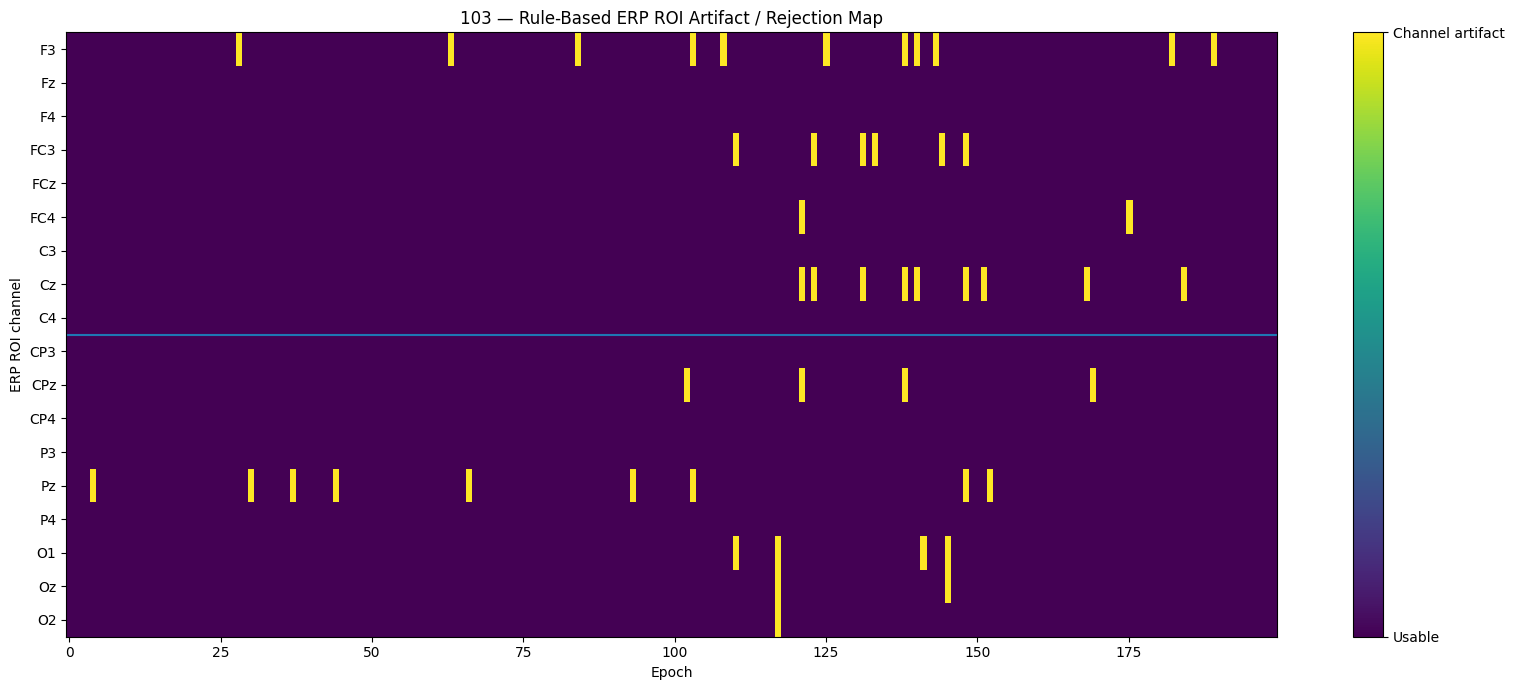

In [50]:
# %% Cell 12 — Rule-based ERP ROI artifact/rejection heatmap

rule_roi_channels = usable_roi_channels

rule_roi_idx = [
    ch_names.index(ch)
    for ch in rule_roi_channels
]

# ------------------------------------------------------------
# Artifact matrix
#
# rows    = usable ERP ROI channels
# columns = epochs
#
# 0 = channel usable in that epoch
# 1 = channel flagged as artifact in that epoch
# ------------------------------------------------------------

rule_artifact_matrix = combined_bad[:, rule_roi_idx].T

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 7))

im = ax.imshow(
    rule_artifact_matrix,
    aspect="auto",
    interpolation="nearest",
    origin="upper",
)

# ------------------------------------------------------------
# Y-axis = channels
# ------------------------------------------------------------

ax.set_yticks(np.arange(len(rule_roi_channels)))
ax.set_yticklabels(rule_roi_channels)

ax.set_xlabel("Epoch")
ax.set_ylabel("ERP ROI channel")

ax.set_title(
    f"{sub} — Rule-Based ERP ROI Artifact / Rejection Map"
)

# ------------------------------------------------------------
# Mark boundary between Early ERP and LPP
# ------------------------------------------------------------

n_early_usable = sum(
    ch in rule_roi_channels
    for ch in EARLY_ERP_ROI
)

if 0 < n_early_usable < len(rule_roi_channels):
    ax.axhline(
        n_early_usable - 0.5,
        linewidth=1.5,
    )

# ------------------------------------------------------------
# Mark whole-epoch rejected trials
#
# These are epochs with >= EPOCH_REJECT_N_ROI
# bad ROI channels.
# ------------------------------------------------------------

rejected_epoch_indices = np.where(
    epoch_reject_rule
)[0]

for epoch_idx in rejected_epoch_indices:
    ax.axvline(
        epoch_idx,
        linewidth=1.5,
        alpha=0.8,
    )

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(im, ax=ax)

cbar.set_ticks([0, 1])
cbar.set_ticklabels([
    "Usable",
    "Channel artifact",
])

plt.tight_layout()
plt.show()

In [51]:
# %% Cell 14 — AutoReject cleaning

status("Running AutoReject...")

ar = AutoReject(
    n_interpolate=[1, 2, 4],
    consensus=[0.50, 0.75, 1.00],
    random_state=42,
    verbose=True,
)

epochs_ar_clean = ar.fit_transform(epochs_master.copy())
reject_log_ar = ar.get_reject_log(epochs_master)

n_original = len(epochs_master)
n_clean = len(epochs_ar_clean)
n_rejected = int(reject_log_ar.bad_epochs.sum())
retention = 100 * n_clean / n_original

print("\nAutoReject results:")
print(f"Original epochs: {n_original}")
print(f"Clean epochs:    {n_clean}")
print(f"Rejected epochs: {n_rejected}")
print(f"Retention:       {retention:.1f}%")
print(f"Selected n_interpolate: {ar.n_interpolate_}")
print(f"Selected consensus:     {ar.consensus_}")


[17:56:03] Running AutoReject...
Running autoreject on ch_type=eeg




Estimated consensus=0.50 and n_interpolate=2
No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.

AutoReject results:
Original epochs: 200
Clean epochs:    200
Rejected epochs: 0
Retention:       100.0%
Selected n_interpolate: {'eeg': 2}
Selected consensus:     {'eeg': 0.5}


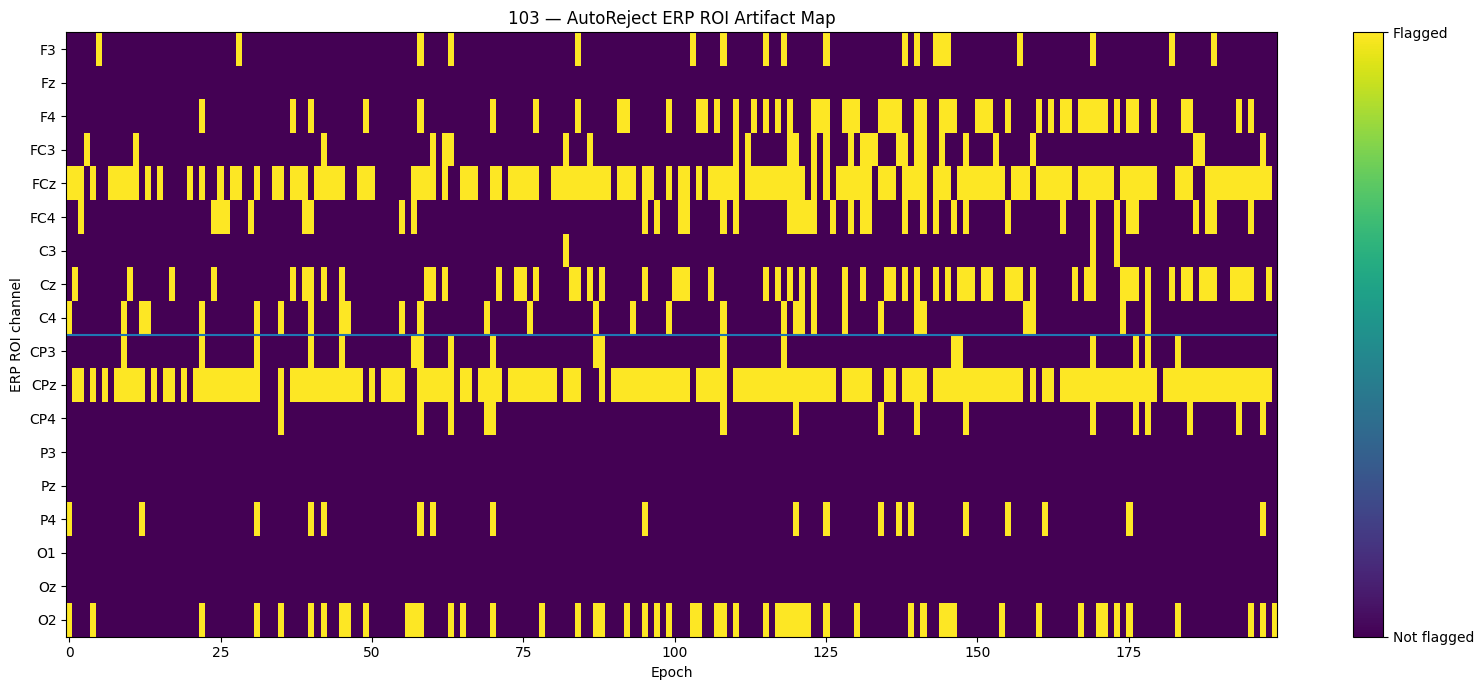

In [27]:
# %% Cell 15 - AutoReject ERP ROI heatmap

ar_roi_idx = [
    epochs_master.ch_names.index(ch)
    for ch in ERP_ROI
]

ar_roi_matrix = (reject_log_ar.labels[:, ar_roi_idx] > 0).T

fig, ax = plt.subplots(figsize=(16, 7))

im = ax.imshow(
    ar_roi_matrix,
    aspect="auto",
    interpolation="nearest",
    origin="upper",
)

ax.set_yticks(np.arange(len(ERP_ROI)))
ax.set_yticklabels(ERP_ROI)

ax.set_xlabel("Epoch")
ax.set_ylabel("ERP ROI channel")
ax.set_title(f"{sub} — AutoReject ERP ROI Artifact Map")

n_early = len(EARLY_ERP_ROI)
ax.axhline(n_early - 0.5, linewidth=1.5)

cbar = fig.colorbar(im, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Not flagged", "Flagged"])

plt.tight_layout()
plt.show()

In [52]:
# %% Create condition-averaged Evokeds — AutoReject

evokeds_ar = {}

for condition in event_id:
    condition_epochs = epochs_ar_clean[
        epochs_ar_clean.metadata["condition"] == condition
    ]

    evokeds_ar[condition] = condition_epochs.average(
        picks="eeg"
    )

print("AutoReject Evokeds:")
for condition, evoked in evokeds_ar.items():
    print(
        f"{condition}: "
        f"{len(evoked.data)} channels, "
        f"{evoked.nave} epochs"
    )

AutoReject Evokeds:
Unpleasant: 26 channels, 40 epochs
Neutral: 26 channels, 40 epochs
Pleasant: 26 channels, 40 epochs
Unpleasant_noise: 26 channels, 40 epochs
Pleasant_noise: 26 channels, 40 epochs
Rule-based Evokeds:
Unpleasant: 26 channels, 40 epochs
Neutral: 26 channels, 40 epochs
Pleasant: 26 channels, 40 epochs
Unpleasant_noise: 26 channels, 40 epochs
Pleasant_noise: 26 channels, 40 epochs


In [53]:

# %% Create condition-averaged Evokeds — Rule-based, ROI-aware

evokeds_rule = {}

for condition in event_id:
    condition_epochs = epochs_rule_clean[
        epochs_rule_clean.metadata["condition"] == condition
    ]

    data = condition_epochs.get_data()  # epochs × channels × times
    metadata = condition_epochs.metadata.reset_index(drop=True)

    # Build channel usability mask for each trial
    usable = np.ones((len(condition_epochs), len(ERP_ROI)), dtype=bool)

    for i, row in metadata.iterrows():
        bad_channels = row["bad_erp_channels"].split(";")
        for ch in bad_channels:
            if ch in ERP_ROI:
                usable[i, ERP_ROI.index(ch)] = False

    # Exclude persistent bad channels if any
    if persistent_channels:
        for ch in persistent_channels:
            if ch in ERP_ROI:
                usable[:, ERP_ROI.index(ch)] = False

    # Extract ROI data and exclude flagged channels per trial
    roi_idx = [condition_epochs.ch_names.index(ch) for ch in ERP_ROI]
    roi_data = data[:, roi_idx, :]

    roi_data[~usable] = np.nan

    # Average over trials separately for each channel
    mean_data = np.nanmean(roi_data, axis=0)

    info = mne.pick_info(
        condition_epochs.info,
        [condition_epochs.ch_names.index(ch) for ch in ERP_ROI]
    )

    evokeds_rule[condition] = mne.EvokedArray(
        mean_data,
        info,
        tmin=condition_epochs.tmin,
        nave=len(condition_epochs),
        comment=condition,
    )

print("Rule-based ROI-aware Evokeds:")
for condition, evoked in evokeds_rule.items():
    print(
        f"{condition}: {len(evoked.ch_names)} ROI channels, "
        f"{evoked.nave} epochs"
    )

Rule-based ROI-aware Evokeds:
Unpleasant: 18 ROI channels, 40 epochs
Neutral: 18 ROI channels, 40 epochs
Pleasant: 18 ROI channels, 40 epochs
Unpleasant_noise: 18 ROI channels, 40 epochs
Pleasant_noise: 18 ROI channels, 40 epochs


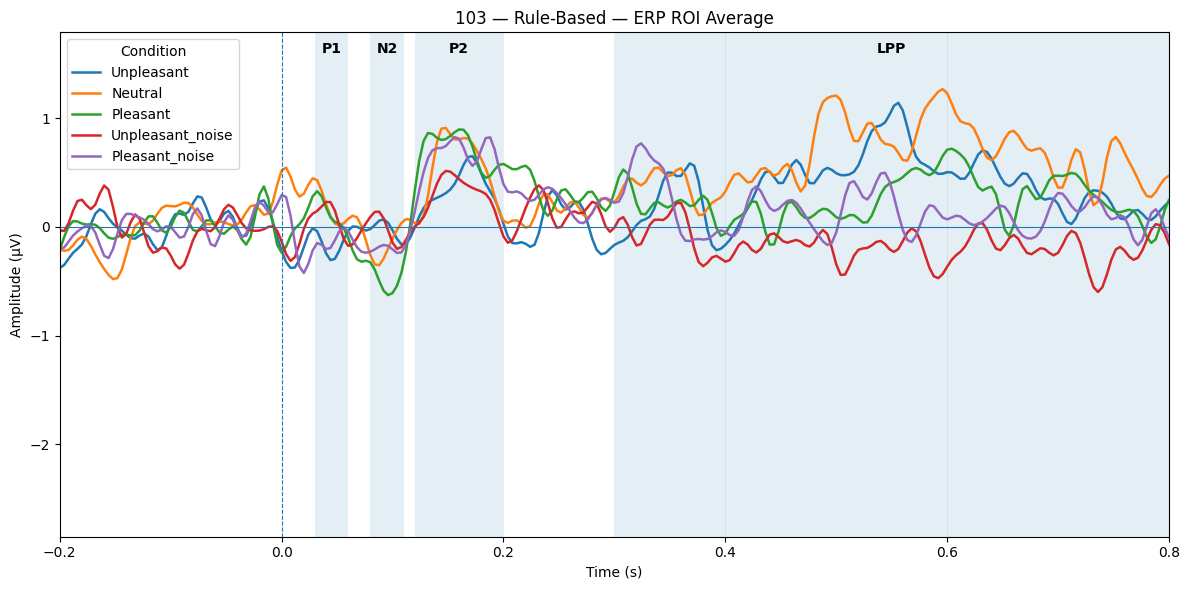

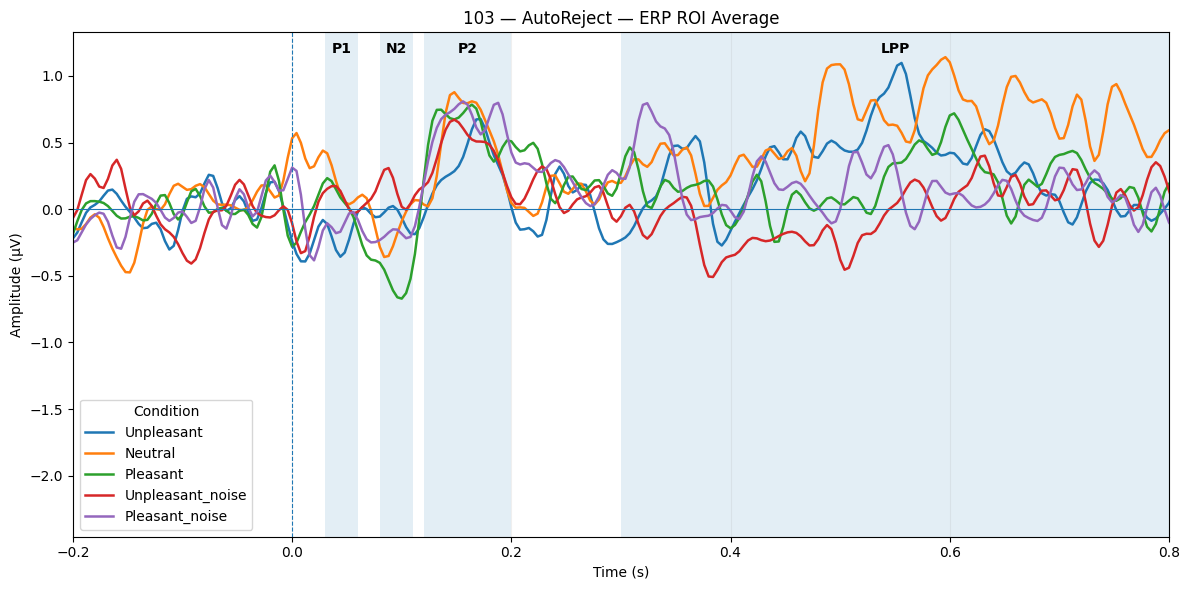

In [54]:
# %% Plot condition-averaged ERPs — Rule-Based
# -200 to +800 ms, with P1/N2/P2/LPP windows marked

COMPONENT_WINDOWS = {
    "P1": (0.030, 0.060),
    "N2": (0.080, 0.110),
    "P2": (0.120, 0.200),
    "LPP": (0.300, 0.800),
}

def plot_condition_erps(evokeds, title_prefix):
    fig, ax = plt.subplots(figsize=(12, 6))

    for condition, evoked in evokeds.items():
        # Average across the ERP ROI
        roi_present = [
            ch for ch in ERP_ROI
            if ch in evoked.ch_names
        ]

        roi_evoked = evoked.copy().pick(roi_present)
        waveform = roi_evoked.data.mean(axis=0) * 1e6

        ax.plot(
            roi_evoked.times,
            waveform,
            label=condition,
            linewidth=1.8,
        )

    # Component windows
    window_alpha = 0.12

    for name, (start, stop) in COMPONENT_WINDOWS.items():
        ax.axvspan(
            start,
            stop,
            alpha=window_alpha,
        )
        ax.text(
            (start + stop) / 2,
            0.98,
            name,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

    # Reference lines
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8, linestyle="--")

    ax.set_xlim(-0.2, 0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(
        f"{sub} — {title_prefix} — ERP ROI Average"
    )

    ax.legend(
        title="Condition",
        loc="best",
        frameon=True,
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()


plot_condition_erps(
    evokeds_rule,
    "Rule-Based",
)

# %% Plot condition-averaged ERPs — AutoReject
# -200 to +800 ms, with P1/N2/P2/LPP windows marked

plot_condition_erps(
    evokeds_ar,
    "AutoReject",
)

In [55]:

# %% Cell xx — Save rule-based outputs

rule_dir = out_dir / "stage3_rule_based"
rule_dir.mkdir(parents=True, exist_ok=True)

# Clean epochs (includes trial-level artifact metadata)
epochs_rule_clean.save(
    rule_dir / f"{sub}_stage3_rule_based_clean-epo.fif",
    overwrite=True,
)

# Artifact masks and decisions
np.savez_compressed(
    rule_dir / f"{sub}_stage3_rule_based_artifact_masks.npz",
    gradient_bad=gradient_bad,
    window_bad=window_bad,
    abs_bad=abs_bad,
    combined_bad=combined_bad,
    roi_bad=roi_bad,
    channel_usable_rule=channel_usable_rule,
    epoch_reject_rule=epoch_reject_rule,
    epoch_keep_rule=epoch_keep_rule,
    bad_channels_usable_roi=bad_channels_usable_roi,
    ch_names=np.array(ch_names),
    usable_roi_channels=np.array(usable_roi_channels),
    persistent_channels=np.array(persistent_channels),
)

# Channel-level diagnostic summary
channel_diagnostics.to_csv(
    rule_dir / f"{sub}_stage3_channel_artifact_diagnostics.csv",
    index=False,
)

# Processing configuration
artifact_config = {
    "thresholds": {
        "gradient_uv_per_ms": GRADIENT_THRESHOLD,
        "window_ptp_uv": WINDOW_PTP_THRESHOLD,
        "absolute_amplitude_uv": ABS_AMPLITUDE_THRESHOLD,
    },
    "persistent_channel_threshold_pct": PERSISTENT_CHANNEL_THRESHOLD,
    "epoch_reject_n_roi": EPOCH_REJECT_N_ROI,
    "epoch_tmin": EPOCH_TMIN,
    "epoch_tmax": EPOCH_TMAX,
    "baseline": list(BASELINE),
    "event_id": event_id,
    "persistent_channels": persistent_channels,
    "usable_roi_channels": usable_roi_channels,
}

with open(rule_dir / f"{sub}_stage3_rule_based_config.json", "w") as f:
    json.dump(artifact_config, f, indent=2)

print(f"Rule-based outputs saved to: {rule_dir}")

Rule-based outputs saved to: Z:\Misophonia_EEG\103\stage3_rule_based


In [56]:

# %% Cell xx — Save AutoReject outputs

ar_dir = out_dir / "stage3_autoreject"
ar_dir.mkdir(parents=True, exist_ok=True)

n_original = len(epochs_master)
n_clean = len(epochs_ar_clean)
n_rejected = int(reject_log_ar.bad_epochs.sum())
retention = 100 * n_clean / n_original

# Cleaned epochs and reject log
epochs_ar_clean.save(
    ar_dir / f"{sub}_stage3_autoreject_clean-epo.fif",
    overwrite=True,
)

np.savez_compressed(
    ar_dir / f"{sub}_stage3_autoreject_log.npz",
    labels=reject_log_ar.labels,
    bad_epochs=reject_log_ar.bad_epochs,
    ch_names=np.array(epochs_master.ch_names),
)

# Channel-level artifact summary
ar_channel_counts = pd.DataFrame({
    "channel": epochs_master.ch_names,
    "bad_count": (reject_log_ar.labels > 0).sum(axis=0),
})
ar_channel_counts["bad_pct"] = 100 * ar_channel_counts["bad_count"] / n_original
ar_channel_counts = ar_channel_counts.sort_values("bad_pct", ascending=False)
ar_channel_counts.to_csv(
    ar_dir / f"{sub}_stage3_autoreject_channel_diagnostics.csv",
    index=False,
)

# Learned thresholds (convert V to µV)
autoreject_thresholds = pd.DataFrame({
    "channel": list(ar.threshes_.keys()),
    "threshold_uv": [x * 1e6 for x in ar.threshes_.values()],
}).sort_values("threshold_uv")
autoreject_thresholds.to_csv(
    ar_dir / f"{sub}_stage3_autoreject_thresholds.csv",
    index=False,
)

# Configuration and results
autoreject_config = {
    "n_interpolate_candidates": [1, 2, 4],
    "consensus_candidates": [0.50, 0.75, 1.00],
    "selected_n_interpolate": int(ar.n_interpolate_["eeg"]),
    "selected_consensus": float(ar.consensus_["eeg"]),
    "random_state": 42,
    "n_original_epochs": n_original,
    "n_clean_epochs": n_clean,
    "n_rejected_epochs": n_rejected,
    "retention_pct": retention,
    "epoch_tmin": EPOCH_TMIN,
    "epoch_tmax": EPOCH_TMAX,
    "baseline": list(BASELINE),
}

with open(ar_dir / f"{sub}_stage3_autoreject_config.json", "w") as f:
    json.dump(autoreject_config, f, indent=2)

print(f"AutoReject outputs saved to: {ar_dir}")
print(f"Epochs: {n_original} → {n_clean}; rejected: {n_rejected}; retention: {retention:.1f}%")

AutoReject outputs saved to: Z:\Misophonia_EEG\103\stage3_autoreject
Epochs: 200 → 200; rejected: 0; retention: 100.0%
